In [1]:
import pandas as pd 
from sqlalchemy import create_engine
import numpy as np 


In [2]:
USER = 'postgres'
PASSWORD = 'Anyasam101'
HOST = 'Localhost'
PORT = '5432'
DB_NAME = 'MONGA'

connection_string = f"postgresql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB_NAME}"
engine = create_engine(connection_string)

query = """
SELECT 
    c.calendar_date,
    mi.item_id,
    mi.item_name,
    COALESCE(SUM(oi.quantity), 0) AS quantity
FROM calendar_dim c
CROSS JOIN menu_items mi
LEFT JOIN orders o ON o.order_timestamp::date = c.calendar_date
LEFT JOIN order_items oi ON oi.order_id = o.order_id AND oi.item_id = mi.item_id
GROUP BY c.calendar_date, mi.item_id, mi.item_name
ORDER BY mi.item_id, c.calendar_date;
"""

In [3]:
try:
    df = pd.read_sql(query, con=engine)
    print(f"Successfully loaded {len(df)} rows.")

    # index=False prevents pandas from writing a row-number column into the CSV
    output_file = "extracted_data.csv"
    df.to_csv(output_file, index=False, encoding='utf-8')
    print(f"Data successfully saved to {output_file}")
except Exception as e:
    print(f"An error occurred: {e}")

finally:
    # 6. Dispose of the engine connection pool
    engine.dispose()

Successfully loaded 112091 rows.
Data successfully saved to extracted_data.csv


In [4]:
df.head()

,calendar_date,item_id,item_name,quantity
0,2022-01-01,M000000001,The King,9
1,2022-01-02,M000000001,The King,3
2,2022-01-03,M000000001,The King,2
3,2022-01-04,M000000001,The King,2
4,2022-01-05,M000000001,The King,4


In [ ]:
# Convert to datetime
df['calendar_date'] = pd.to_datetime(df['calendar_date'])

# Group by item to create time-series window features
grouped = df.groupby('item_id')['quantity']

df['lag_qty_1_day'] = grouped.shift(1)
df['lag_qty_7_day'] = grouped.shift(7).fillna(0)
df['rolling_avg_mean_7_day'] = grouped.transform(lambda x: x.rolling(8, min_periods=1).mean()).round(2)

# Date Features
df['day_of_week'] = df['calendar_date'].dt.dayofweek + 1  # 1=Mon, 7=Sun (ISODOW)
df['is_weekend'] = df['calendar_date'].dt.dayofweek.isin([5, 6]).astype(int)
df['is_payday'] = df['calendar_date'].dt.day.isin([15, 30, 31]).astype(int)

df.replace(np.nan, 0)

,calendar_date,item_id,item_name,quantity,lag_qty_1_day,lag_qty_7_day,rolling_avg_mean_7_day,day_of_week,is_weekend,is_payday
0,2022-01-01,M000000001,The King,9,0.0,0.0,9.00,6,1,0
1,2022-01-02,M000000001,The King,3,9.0,0.0,6.00,7,1,0
2,2022-01-03,M000000001,The King,2,3.0,0.0,4.67,1,0,0
3,2022-01-04,M000000001,The King,2,2.0,0.0,4.00,2,0,0
4,2022-01-05,M000000001,The King,4,2.0,0.0,4.00,3,0,0
...,...,...,...,...,...,...,...,...,...,...
112086,2026-07-27,SKU_57,Bottled Water,7,3.0,4.0,4.12,1,0,0
112087,2026-07-28,SKU_57,Bottled Water,3,7.0,2.0,4.00,2,0,0
112088,2026-07-29,SKU_57,Bottled Water,1,3.0,5.0,3.88,3,0,0
112089,2026-07-30,SKU_57,Bottled Water,11,1.0,4.0,4.62,4,0,1


In [ ]:
df[['quantity', 'total_price']].describe()

,quantity,total_price
count,270000.000000,270000.000000
mean,1.306907,237.818248
std,0.517356,156.476965
min,1.000000,30.000000
25%,1.000000,120.000000
50%,1.000000,219.000000
75%,2.000000,290.000000
max,3.000000,1050.000000


In [ ]:
df.isnull().sum()

order_id           0
order_timestamp    0
store_id           0
store_name         0
item_name          0
category           0
quantity           0
unit_price         0
total_price        0
order_date         0
order_year         0
dtype: int64

<Axes: >

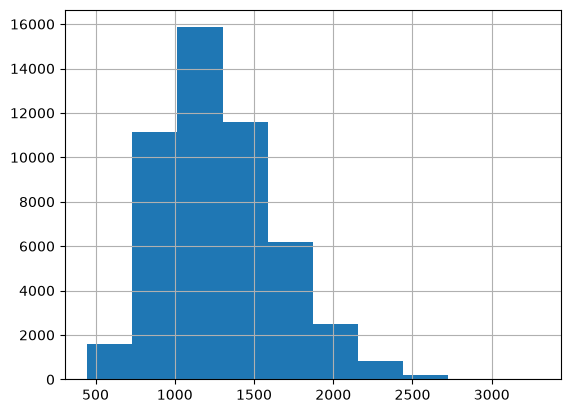

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df_orders = df.groupby('order_id')[['total_price']].sum()
df_orders['total_price'].hist(bins=10)

C:\Users\91460\AppData\Local\Temp\ipykernel_18088\4154941335.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(category_sales, x='category', y='total_price', palette='Reds', ax=ax)


<Axes: xlabel='category', ylabel='total_price'>

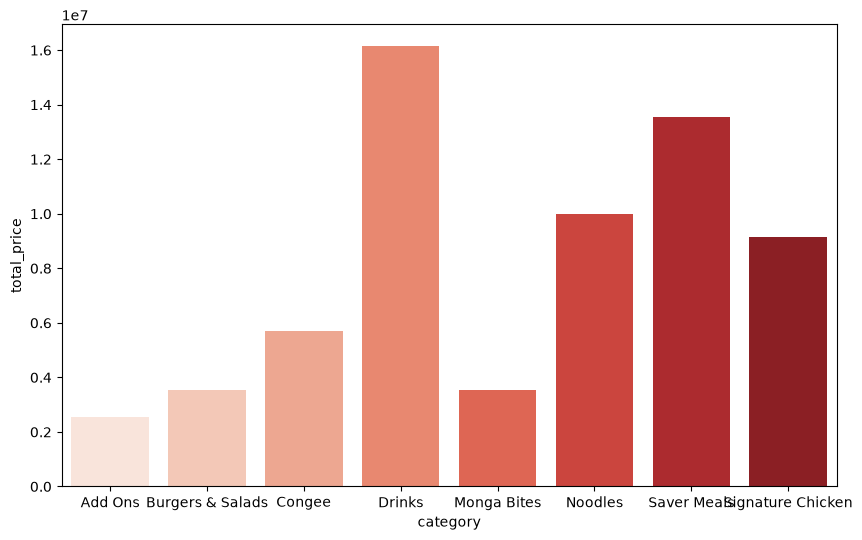

In [ ]:
category_sales = df.groupby('category')[['total_price']].sum()

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(category_sales, x='category', y='total_price', palette='Reds', ax=ax)

C:\Users\91460\AppData\Local\Temp\ipykernel_18088\2675976973.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(store_sales, x='store_name', y='total_price', ax=ax, palette="Reds")


Text(0.5, 0, 'Store')

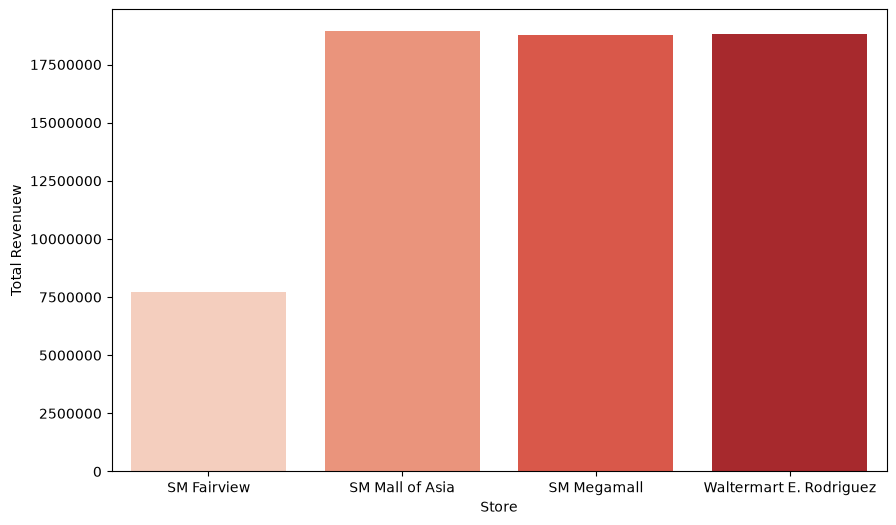

In [ ]:
store_sales = df.groupby('store_name')[['total_price']].sum()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(store_sales, x='store_name', y='total_price', ax=ax, palette="Reds")

ax.ticklabel_format(style='plain', axis='y')
ax.set_ylabel(ylabel='Total Revenuew')
ax.set_xlabel(xlabel='Store')

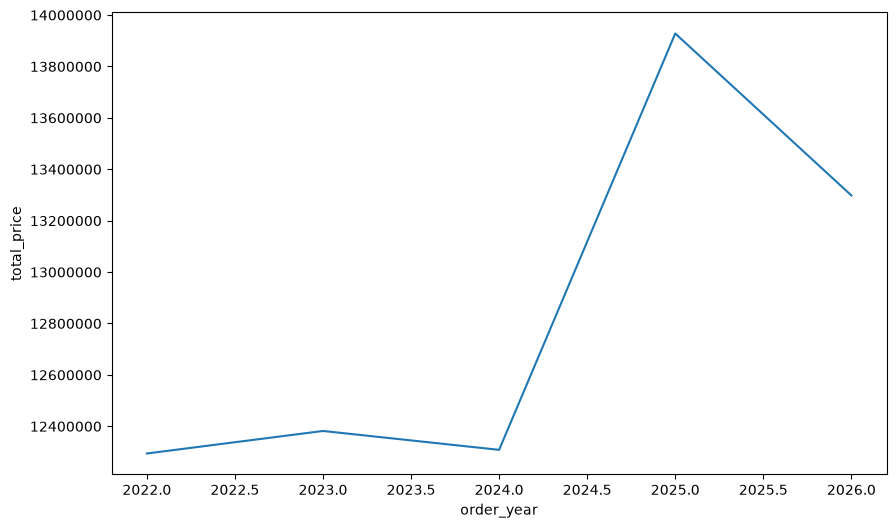

In [ ]:
date_totals = df.groupby('order_year')[['total_price']].sum()
fig, ax = plt.subplots(figsize=(10,6))
sns.lineplot(data=date_totals, x='order_year', y='total_price', ax=ax)
ax.ticklabel_format(style='plain', axis='y')
